In [189]:
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [190]:
# matplotlib 폰트깨짐 방지
os_name = platform.system()
if os_name == "Windows":
    plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우
elif os_name == "Darwin":
    plt.rcParams['font.family'] = 'AppleGothic'   # 맥북
else:
    plt.rcParams['font.family'] = 'NanumGothic'   # 기타(코랩 등)

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 1. 탐색적 데이터 분석(EDA) 및 전처리 파이프라인 구현

**1️⃣ 구현 내용**

**[필수] 구현 내용**

| **구현 내용** | **설명** |
| --- | --- |
| **[문항 1-1] 데이터 구조 탐색 및 기초 분석** | 당뇨병 데이터셋(`diabetes.csv`)을 불러온 뒤, 데이터의 전반적인 행과 열의 크기, 변수별 데이터 타입, 결측치 및 이상치의 존재 여부를 확인하는 코드를 구현합니다. |
| **[문항 1-2] 전처리 파이프라인 구축** | 분석된 결과를 바탕으로 결측치 처리(특히 생리학적 오류인 0값의 정제), 데이터 스케일링, 범주형 변수 인코딩을 수행하는 전처리 코드를 작성합니다. |

**[심화] 구현 내용**

| **구현 내용** | **설명** |
| --- | --- |
| **[문항 1-2] 데이터 시각화 및 인사이트 도출** | Matplotlib 라이브러리를 활용하여 주요 변수들의 분포와 변수 간의 상관관계를 보여주는 시각화 그래프를 생성하고, 이를 바탕으로 데이터의 특성을 분석한 통계적 인사이트를 기술합니다. |
| **[문항 1-2] 전처리 선택 근거 제시** | 해당 전처리 기법(결측치 대체 방식 및 스케일러 종류 등)을 선택하여 프로젝트에 적용한 명확한 분석적 근거를 마크다운 셀에 설명합니다. |

**2️⃣ 결과물**

- **[문항 1-1 결과물]:** 노트북 내 데이터 로드 및 데이터 구조(shape, info, 결측치 등) 확인 소스 코드와 출력 화면
- **[문항 1-2 결과물]:** 데이터의 분포 및 상관관계를 나타내는 시각화 차트 이미지와 데이터 특성 분석 내용 (마크다운 셀)
- [문항 1-3 결과물]: 결측치, 스케일링, 인코딩이 적용된 전처리 파이프라인 코드 및 전처리 방식별 선택 근거 요약 글 (마크다운 셀)

## 데이터셋 - Diabetes.csv
다양한 신체 지표를 활용하여 환자가 당뇨가 있는지 없는지 예측하기 위해 구축된 데이터셋

- Pregnancies: 임신 횟수
- Glucose: 포도당 부하 검사 수치
- BloodPressure: 혈압 (mm Hg)
- SkinThickness: 삼두근 피부 주름 두께 (mm)
- Insulin: 혈중 인슐린 (2-hour, mu U/ml)
- BMI: 체질량 지수 (\(\text{체중(kg)} / \text{신장(m)}^2\))
- DiabetesPedigreeFunction: 당뇨병 혈통 가중치 함수
- Age: 나이 (세)
- Outcome: 당뇨병 발병 유무 (0 또는 1, 타겟 변수)

In [191]:
data = pd.read_csv('./src/data/diabetes.csv', encoding='utf-8')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## info() 정보 확인
- 총 768개의 데이터 샘플
- 전체 컬럼의 자료형은 정수형 또는 실수형
- `null` 값은 없지만 결측치가 `0` 등의 값으로 채워져 있을 가능성 있음
  - `Glucose`	`BloodPressure`	`SkinThickness`	`Insulin`	`BMI`의 최소값이 완벽한 0인 것은 정상적이지 않은 것으로 보임	

In [192]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [193]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 데이터셋으로부터 확인된 사항
- 타겟값인 `Outcome`은 0 또는 1의 바이너리 값을 가지며, 전체 데이터셋에서 당뇨병 환자는 약 35% 비중
- `Pregnancy`를 제외한 나머지 컬럼은 현실적으로 0이 될 수 없을 가능성이 높다 = 결측치일 가능성

## checklist
- 0이 결측치라면, 결측치 모두를 drop했을 때 데이터셋 사이즈가 얼마나 변하는지 확인 필요
  - 전체 대비 10% 미만 수준이라면 모두 drop하고, 유의미한 갯수라면 다른 값으로 대체한다

In [194]:
# 'Pregnancies', 'Outcome' 컬럼을 제외한 나머지 컬럼에서 값이 0인 데이터 샘플 갯수 출력
for colname in data.columns:
  if colname in ['Pregnancies', 'Outcome']:
    continue
  print(f"{colname} : {(data[colname]==0).sum()}")

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11
DiabetesPedigreeFunction : 0
Age : 0


## AI 활용 - 0으로 기록된 값의 결측치 여부 확인


| 특성명 | 0의 생리학적 가능 여부 | 결측치로 보는 이유 |
| --- | --- | --- |
| **Glucose** (공복 혈당) | **불가능** | 혈중 포도당 농도가 0이면 뇌세포 괴사 및 사망에 이릅니다. 생존자의 혈당은 0이 될 수 없습니다. |
| **BloodPressure** (이완기 혈압) | **불가능** | 이완기 혈압이 0이라는 것은 혈류 순환이 완전히 멈춘 심정지 상태를 의미합니다. |
| **SkinThickness** (삼두근 피부 주름 두께) | **불가능** | 캘리퍼로 피하지방과 피부를 집어 측정하는 단위(mm)로, 0은 피부와 피하지방의 물리적 두께가 아예 없다는 모순이 발생합니다. |
| **BMI** (체질량지수) | **불가능** | $\text{체중} / (\text{키})^2$ 공식 특성상 몸무게나 키가 0이 아닌 이상 0이 나올 수 없습니다. |
| **Insulin** (2시간 혈청 인슐린) | **극히 예외적이나 실질적 결측치** | 1형 당뇨나 극단적 췌장 기능 상실 시 검출 한계(LoD) 미만으로 측정될 수는 있으나, 전체 샘플(768건) 중 절반 가까이(374건)가 0인 것은 당시 검사 생략·누락이 대다수임을 뜻합니다. |

**실무 전처리 가이드**

* **0을 `np.nan`으로 변환:** 그대로 학습시키면 회귀 계수 왜곡이나 트리 분기 왜곡이 발생하므로, 먼저 0을 결측치로 바꾼 뒤 처리해야 합니다.

**결측치 비율에 따른 처리 전략:**
* **Glucose, BloodPressure, BMI:** 결측치 비율이 매우 낮으므로 중앙값(median) 또는 평균 대체가 안전하며, 행을 삭제해도 손실이 적습니다.
* **SkinThickness, Insulin:** 결측치가 30~50%에 달하므로 단순 평균 대체 시 분포 왜곡이 심합니다. KNN이나 반복 대치(IterativeImputer)를 쓰거나, `Insulin_Missing` 여부를 나타내는 별도의 이진 특성(0/1)을 함께 만들어 결측 패턴 자체를 정보로 활용하는 방식이 효과적입니다.

## 의사결정
* 'Pregnancies', 'Outcome'을 제외한 모든 컬럼에서 등장하는 0값은 모두 결측치로 판단
* 'Glucose', 'BloodPressure', 'BMI' 결측치를 모두 drop할 경우 삭제되는 샘플은 44개 -> 전체의 6% 수준으로 모두 드랍
* 'SkinThickness', 'Insulin' 결측치는 np.nan으로 대체하며, 각 컬럼의 결측치 존재 여부를 표현하는 'SkinThickness_Missing', 'Insulin_Missing' 컬럼을 추가
  * 결측 여부 정보가 당뇨 예측에 유의미한 정보라고 판단하여, 결측 여부를 표현하는 추가 컬럼을 생성한다

In [195]:
# Glucose, BloodPressure, BMI 컬럼 중 하나라도 값이 0인 데이터 샘플의 총 갯수 출력
is_glucose_zero = data['Glucose'] == 0
is_bloodpressure_zero = data['BloodPressure'] == 0
is_bmi_zero = data['BMI'] == 0
print(len(data[is_glucose_zero | is_bloodpressure_zero | is_bmi_zero]))


44


In [196]:
# 값이 0인 데이터 드랍 후 데이터 샘플 갯수가 44개 줄었는지 확인
print('drop 전 샘플 갯수', len(data))
data = data.drop(data[is_glucose_zero | is_bloodpressure_zero | is_bmi_zero].index)
print('drop 후 샘플 갯수', len(data))

drop 전 샘플 갯수 768
drop 후 샘플 갯수 724


In [197]:
# SkinThickness, Insulin 컬럼의 값이 0인지 여부를 0 또는 1로 표현하는 컬럼 생성 (특성 공학)
data['SkinThickness_Missing'] = (data['SkinThickness'] == 0)
data['Insulin_Missing'] = (data['Insulin'] == 0)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,SkinThickness_Missing,Insulin_Missing
0,6,148,72,35,0,33.6,0.627,50,1,False,True
1,1,85,66,29,0,26.6,0.351,31,0,False,True
2,8,183,64,0,0,23.3,0.672,32,1,True,True
3,1,89,66,23,94,28.1,0.167,21,0,False,False
4,0,137,40,35,168,43.1,2.288,33,1,False,False


In [198]:
# 이후 전처리 작업을 진행하기 위하여 0 값을 np.nan(Null)으로 교체
data.loc[data['SkinThickness'] == 0, 'SkinThickness'] = np.nan
data.loc[data['Insulin'] == 0, 'Insulin'] = np.nan

In [199]:
data.info() # SkinThickness, Insulin 특성에만 Null 값이 존재한다.

<class 'pandas.DataFrame'>
Index: 724 entries, 0 to 767
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               724 non-null    int64  
 1   Glucose                   724 non-null    int64  
 2   BloodPressure             724 non-null    int64  
 3   SkinThickness             532 non-null    float64
 4   Insulin                   392 non-null    float64
 5   BMI                       724 non-null    float64
 6   DiabetesPedigreeFunction  724 non-null    float64
 7   Age                       724 non-null    int64  
 8   Outcome                   724 non-null    int64  
 9   SkinThickness_Missing     724 non-null    bool   
 10  Insulin_Missing           724 non-null    bool   
dtypes: bool(2), float64(4), int64(5)
memory usage: 58.0 KB


## 'SkinThickness', 'Insulin' 결측치: `np.nan` vs. `median` (Gemini 활용)

결론부터 말씀드리면, `np.nan` 변환과 `중앙값 대체`는 서로 경쟁하는 대안이 아니라 **전처리의 서로 다른 단계**입니다.

기존의 `0`은 시스템이 '유효한 측정값 0'으로 인식하지만, `np.nan`은 시스템에 **'여기는 비어 있는 값'이라고 선언하는 표준 표기**입니다. 즉, `0`을 `np.nan`으로 바꾸는 것은 올바른 첫 단계이며, 그 상태를 모델 학습 전까지 그대로 둘 때와 중앙값으로 채울 때의 비교는 다음과 같습니다.

| 구분 | `np.nan` 상태 유지 | `중앙값(Median)` 대체 |
| --- | --- | --- |
| **장점** | • **데이터 왜곡 제로**: 원래 수집된 실제 값들의 통계량(평균, 분산, 왜도)을 전혀 오염시키지 않음.<br><br>• **고급 결측치 처리 가능**: 단순 채우기 대신 KNN, MICE(다중대치법), 결측 지표 생성 등 더 정교한 기법을 적용할 준비가 됨.<br><br>• **일부 트리 모델 호환**: XGBoost, LightGBM 등은 `NaN` 자체를 트리 분기 조건으로 직접 학습할 수 있음. | • **모든 알고리즘 지원**: 로지스틱 회귀, SVM, 신경망 등 결측치를 허용하지 않는 전통적 모델에 즉시 입력 가능.<br><br>• **이상치에 강건함**: 평균과 달리 극단값에 휘둘리지 않아 비교적 안정적인 대푯값을 제공함.<br><br>• **구현이 단순함**: 파이프라인 구성이 빠르고 직관적임. |
| **단점** | • **로지스틱 회귀 입력 불가**: 사이킷런의 `LogisticRegression`은 입력 데이터에 `NaN`이 하나라도 있으면 `ValueError` 에러를 발생시킴.<br><br>• **행 삭제 유발 위험**: 별도 대치 없이 진행하면 분석 도구가 해당 행을 전부 삭제(`dropna`)하여 전체 데이터의 절반 가까이를 잃게 됨. | • **분포 왜곡(첨도 급증)**: 768개 중 374개가 동일한 중앙값 하나로 뭉치면서 해당 지점의 확률 밀도가 비정상적으로 치솟고 분산이 줄어듦.<br><br>• **변수 간 관계 훼손**: 다른 특성(혈당, 나이 등)과 상관없이 일괄 대체되므로 인슐린과의 실제 상관관계가 희석됨. |

**권장 전처리 흐름**

로지스틱 회귀를 사용하기로 결정하셨다면, 현재 `np.nan`으로 바꾼 상태에서 멈추지 않고 아래 두 작업 중 하나를 거쳐야 모델이 돌아갑니다.

1. **중앙값 대체 + 결측 지표 병행 (가장 무난한 방법)**
* 앞서 다룬 것처럼 `Insulin_Missing` 지표(0/1)를 만들어 결측 사실을 보존한 뒤, `np.nan` 자리는 중앙값으로 채워 에러를 방지합니다.


2. **반복 대치(IterativeImputer / MICE) 적용 (분포 왜곡 최소화)**
* 결측치가 30~50%로 많은 특성이므로, 단순 중앙값 대신 환자의 나이, 혈당, BMI 등을 기반으로 인슐린 값을 다변량 회귀로 추정해 채워 넣는 방식입니다.


## 의사결정
- 분포 왜곡 최소화를 위하여, 다변량 회귀 모델을 사용하여 'SkinThickness', 'Insulin' 결측치를 예측값으로 채운다.

In [200]:
from sklearn.model_selection import train_test_split

# IterativeImputer 활성화 및 임포트 (반드시 enable_iterative_imputer 먼저 호출)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

In [201]:
# 특성(X)과 타겟(y) 분리 및 Train/Test 분할 (데이터 누수 방지)
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# 데이터셋을 8:2 비율로 학습용 셋과 테스트 셋으로 나눈다.
# 당뇨병 예측이 아닌 결측치를 채우기 위한 목적이지만, 전체 데이터셋을 활용하여 결측치를 예측할 경우
# 결측치 예측값 자체에 이후 테스트셋의 "정답" 정보가 이미 포함되어, 데이터 누수가 발생하게 된다.
# 따라서, 이후 당뇨병 예측에 활용할 훈련 데이터셋과 테스트 데이터셋을 미리 나누어 훈련 데이터셋의 정보로만 결측치를 예측한다.

# 결과값 재현을 위한 random_state 설정 / stratify -> 타겟값(당뇨여부) 비율을 동일하게 맞추기
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

# IterativeImputer 설정
# - estimator: 기본값은 BayesianRidge (필요 시 RandomForestRegressor 등 교체 가능)
# - min_value=0: 인슐린, 혈압 등 생체 측정값이 음수로 대치되는 현상 방지
# - add_indicator=True: 대치와 동시에 결측 여부 지표(0/1) 컬럼 자동 생성
imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42,
    min_value=0,
    add_indicator=False
)

# Train 세트로 학습 후 Train/Test 세트 각각 대치
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 컬럼명을 유지한 DataFrame 형태로 재변환
feature_names = imputer.get_feature_names_out()
X_train_clean = pd.DataFrame(X_train_imputed, columns=feature_names, index=X_train.index)
X_test_clean = pd.DataFrame(X_test_imputed, columns=feature_names, index=X_test.index)

In [202]:
X_train_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,SkinThickness_Missing,Insulin_Missing
200,0.0,113.0,80.0,16.000000,119.440804,31.0,0.874,21.0,0.0,1.0
4,0.0,137.0,40.0,35.000000,168.000000,43.1,2.288,33.0,0.0,0.0
394,4.0,158.0,78.0,29.998321,220.717298,32.9,0.803,31.0,1.0,1.0
436,12.0,140.0,85.0,33.000000,181.606945,37.4,0.244,41.0,0.0,1.0
581,6.0,109.0,60.0,27.000000,117.934914,25.0,0.206,27.0,0.0,1.0


## 데이터 스케일링 전 Boxplot - 수치형 특성 컬럼 분포 확인
- numeral 타입의 컬럼의 분포 상태를 먼저 확인한 뒤, 적합한 Scaler 선택하기

## Boxplot 시각화 분석 (Gemini 활용)
이상치(Outlier)에 가장 견고(Robust)한 스케일러는 Scikit-Learn의 `RobustScaler`입니다.

피마 데이터셋은 `Insulin`, `DiabetesPedigreeFunction`, `Age` 등에 심한 오른쪽 꼬리(Right-skewed) 분포와 극단적인 이상치가 존재합니다. 이 상태에서 표준 정규분포화(StandardScaler)나 최소-최대 정규화(MinMaxScaler)를 쓰면 이상치가 전체 축을 심하게 왜곡하므로, 사분위수(IQR) 기반의 `RobustScaler`를 사용하는 것이 최선입니다.

또한, 이전 단계에서 생성된 결측 지표(0/1 이진 컬럼)는 이미 0과 1로 정규화되어 있으므로, `ColumnTransformer`를 사용해 연속형 수치 컬럼만 스케일링하고 결측 지표 컬럼은 그대로 통과(`passthrough`)시키는 것이 핵심입니다.

### `RobustScaler` 선정 근거 및 원리

#### 1. 계산 공식 비교

* **StandardScaler**: $z = \frac{x - \mu}{\sigma}$ (평균 $\mu$과 표준편차 $\sigma$ 사용)
* **RobustScaler**: $z = \frac{x - Q_2}{Q_3 - Q_1} = \frac{x - \text{Median}}{\text{IQR}}$ (중앙값과 사분위범위 사용)

| 스케일러 | 이상치 취약점 | 피마 데이터 적용 시 결과 |
| --- | --- | --- |
| **StandardScaler** | 이상치가 1개만 있어도 평균($\mu$)이 끌려가고 표준편차($\sigma$)가 비정상적으로 커짐 | 정상 범위 환자들의 값이 좁은 구간에 비정상적으로 뭉침 |
| **MinMaxScaler** | 최댓값/최솟값에 절대적으로 의존함 | 극단적 고인슐린 환자(예: 800) 때문에 대다수 일반 환자의 인슐린 수치가 0.0~0.2 사이에 압축됨 |
| **RobustScaler** | 50% 지점(중앙값)과 25~75% 구간(IQR)만 기준으로 삼아 **극단값의 영향을 전혀 받지 않음** | 극단치가 있어도 일반 환자 데이터의 간격과 상대적 차이가 보존됨 |

#### 2. 결측 지표(0/1) 컬럼을 `passthrough` 시킨 이유
결측 여부를 나타내는 컬럼(예: `missingindicator_Insulin`)을 스케일링해 버리면, 값(0과 1)이 `-0.35`, `1.42` 같은 임의의 실수로 변환됩니다.
* 이렇게 되면 로지스틱 회귀에서 "결측 여부(0 또는 1)"에 따른 회귀 계수(Odds Ratio)의 직관적 해석력이 완전히 상실됩니다.
* 따라서 `ColumnTransformer`를 사용해 **순수 측정값만 스케일링하고, 이진 플래그는 0과 1 상태 그대로 로지스틱 회귀에 전달**하는 것이 모범 사례입니다.


## 의사결정
- 인슐린 컬럼 등에 800 이상의 극단적인 이상치가 존재하나, 해당 이상치가 유의미한지 아닌지를 판단할 도메인 지식 또는 근거가 없는 상태.
- 정보가 충분하지 않은 상태이므로, RobustScaler로 이상치를 모두 배제시키는 것보다는 우선 StandardScaler를 적용하는 것이 적절하다고 보여짐

### StandardScaler 선택 이유
- 데이터의 평균을 0, 표준편차를 1로 맞추어 데이터가 평균으로부터 얼마나 떨어져 있는지 '표준 점수(Z-Score)'로 변환
- "데이터가 정상 분포라는 가정 하에" 원본 특성값들의 분포를 그대로 살려주는 스케일러이기 때문에 채택하였음
  - "데이터가 비정상 분포"라는 가정을 확인 가능할 시 RobustScaler 등을 검토할 수 있음

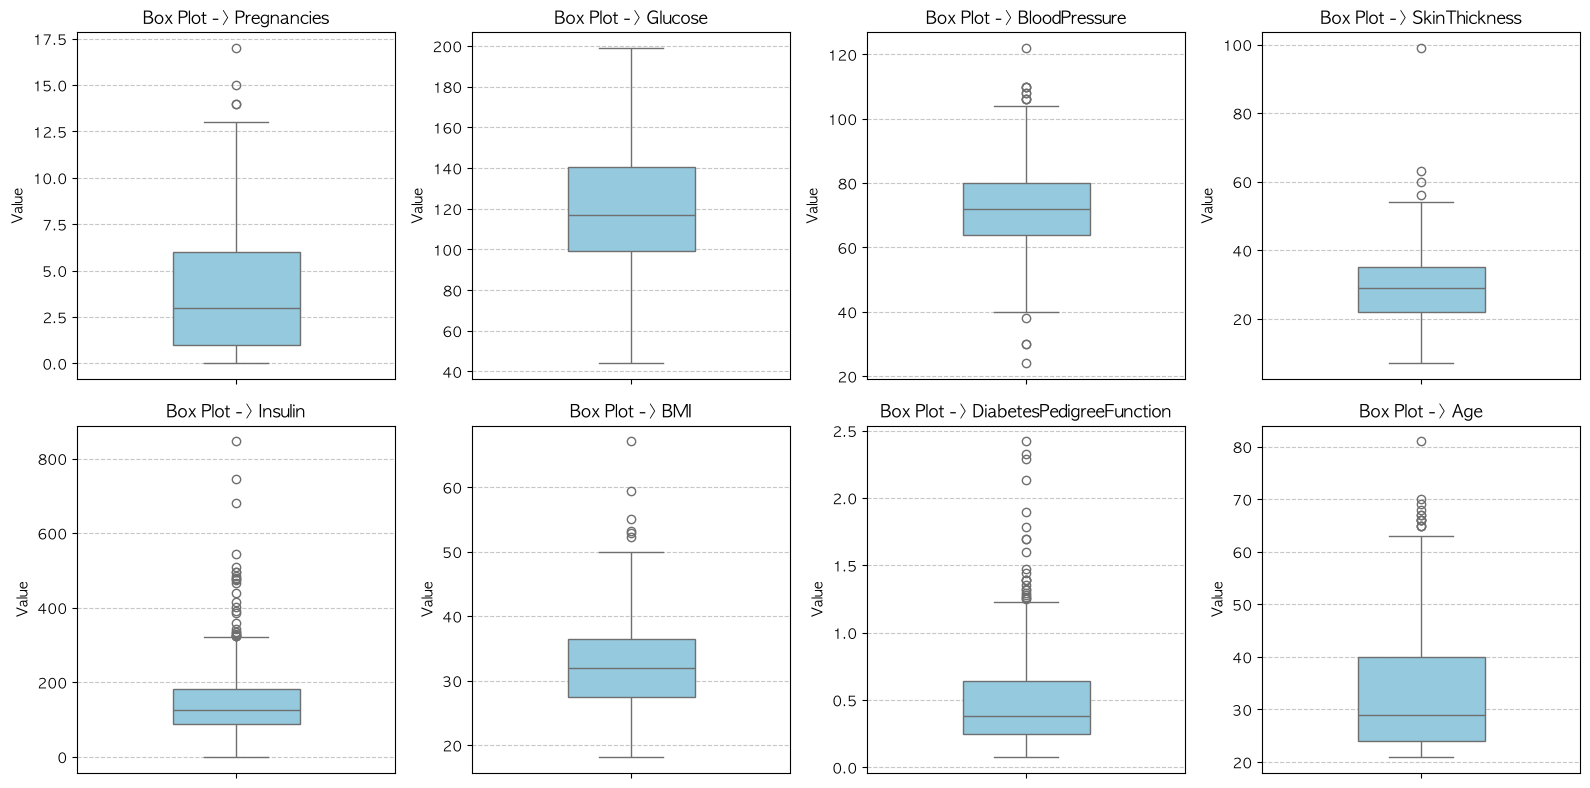

In [203]:
# 1. 시각화 대상 연속형 수치 컬럼 지정
numeric_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 
    'SkinThickness', 'Insulin', 'BMI', 
    'DiabetesPedigreeFunction', 'Age'
]

# 2. 2행 4열 서브플롯 캔버스 생성
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()  # 2D 배열을 1D로 평탄화하여 반복문 접근 용이하게 설정

# 3. 반복문을 통해 각 컬럼별 박스 플롯 생성
# (결측치 대체 완료된 df_clean 또는 X_train_clean 데이터프레임 기준)
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=X_train_clean[col], ax=axes[i], color='skyblue', width=0.4)
    axes[i].set_title(f'Box Plot -> {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# 4. 레이아웃 여백 자동 정렬 및 출력
plt.tight_layout()
plt.show()

In [204]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# 이전 단계에서 결측치 처리(IterativeImputer)가 완료된 상태
# (X_train_clean, X_test_clean에 결측치 대체 완료 및 결측지표 생성 완료)

# 연속형 수치 컬럼과 결측 지표(이진 0/1) 컬럼 구분
original_numeric_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 
    'SkinThickness', 'Insulin', 'BMI', 
    'DiabetesPedigreeFunction', 'Age'
]

# 결측 지표 컬럼명 추출 (예: 'missingindicator_Insulin' 형태)
indicator_cols = [col for col in X_train_clean.columns if col not in original_numeric_cols]

# ColumnTransformer 구성
# - original_numeric_cols: StandardScaler 적용
# - indicator_cols: passthrough (변환 없이 원본 0/1 유지)
preprocessor = ColumnTransformer(
    transformers=[
        ('standard_scale', StandardScaler(), original_numeric_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False # 컬럼명 접두사 생략 옵션
)

# 데이터 누수 방지를 위해 Train 세트로만 fit 후 변환
X_train_scaled = preprocessor.fit_transform(X_train_clean)
X_test_scaled = preprocessor.transform(X_test_clean)

# 판다스 데이터프레임으로 복원 (컬럼 순서 및 이름 유지)
feature_names = preprocessor.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train_clean.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test_clean.index)

print("스케일링 완료된 Train 데이터 상위 5개 행:")
print(X_train_final.head())

스케일링 완료된 Train 데이터 상위 5개 행:
     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
200    -1.119892 -0.281756       0.615198      -1.313613 -0.293465 -0.196809   
4      -1.119892  0.498491      -2.569419       0.621280  0.211736  1.572273   
394     0.085345  1.181207       0.455967       0.111927  0.760196  0.080981   
436     2.495819  0.596022       1.013275       0.417607  0.353300  0.738904   
581     0.687963 -0.411797      -0.977111      -0.193411 -0.309131 -1.074039   

     DiabetesPedigreeFunction       Age  SkinThickness_Missing  \
200                  1.140646 -1.027568                    0.0   
4                    5.247773  0.001778                    0.0   
394                  0.934418 -0.169780                    1.0   
436                 -0.689262  0.688009                    0.0   
581                 -0.799637 -0.512895                    0.0   

     Insulin_Missing  
200              1.0  
4                0.0  
394              1.0  
43

In [205]:
# 데이터 EDA 및 시각화를 위하여 다시 합치기
y = pd.concat([y_train, y_test])
X_clean = pd.concat([X_train_final, X_test_final])
X_clean.info()

<class 'pandas.DataFrame'>
Index: 724 entries, 200 to 592
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               724 non-null    float64
 1   Glucose                   724 non-null    float64
 2   BloodPressure             724 non-null    float64
 3   SkinThickness             724 non-null    float64
 4   Insulin                   724 non-null    float64
 5   BMI                       724 non-null    float64
 6   DiabetesPedigreeFunction  724 non-null    float64
 7   Age                       724 non-null    float64
 8   SkinThickness_Missing     724 non-null    float64
 9   Insulin_Missing           724 non-null    float64
dtypes: float64(10)
memory usage: 62.2 KB


In [206]:
# X_clean과 y의 인덱스가 모두 동일한지 확인
print((X_clean.index == y.index).sum() == len(X))

True


## 최종 데이터 시각화
- 결측치 전처리 / 특성 공학(피쳐 엔지니어링) / 데이터 스케일링 완료
- 0/1 바이너리 특성 컬럼(`INSULIN_MISSING`, `SKINTHICKNESS_MISSING`)은 그대로 사용
  - Logistic Regression 기준, 현재 상태로 유의미함

## 시각화를 통한 데이터 특성 분석


제공해주신 상관계수 히트맵과 산점도 행렬(Scatter Matrix)을 바탕으로 분석한 각 특성별 핵심 특징입니다.

| 특성명 | 타겟(`Outcome`) 상관성 | 다중공선성 및 분포 특징 | 모델링 관점의 분석 및 시사점 |
| --- | --- | --- | --- |
| **Glucose** | **0.49 (가장 높음)** | `Insulin`과 강한 양의 상관관계(**0.68**)를 보이며, 산점도에서 뚜렷한 선형 궤적 확인 | 당뇨병 유무(붉은 점 vs 파란 점)를 가장 명확히 가르는 **핵심 예측 인자**입니다. |
| **Insulin** | **0.34 (높음)** | `Glucose`와의 상관계수가 0.68로 매우 높으며, 대치(Imputation) 후에도 우측 꼬리가 두터운 편 | 단독 예측력은 우수하나, Glucose와의 강한 상관관계로 인해 선형 모델에서 회귀 계수 왜곡(다중공선성)을 유발할 수 있습니다. |
| **BMI** | **0.30 (보통 이상)** | `SkinThickness`와 매우 높은 상관관계(**0.70**) | 비만 지표로서 당뇨 발병과 유의미한 양의 관계를 가지며, 체지방 두께와 정보가 강하게 겹칩니다. |
| **SkinThickness** | **0.27 (보통)** | `BMI`와 상관계수 **0.70**, 산점도 상에서도 뚜렷한 대각선 비례 관계 형성 | BMI와 설명력이 중복되므로, 로지스틱 회귀 학습 시 규제(L1/L2)를 주거나 둘 중 하나를 선택적으로 고려할 필요가 있습니다. |
| **Age** | **0.25 (보통)** | `Pregnancies`와 강한 양의 상관관계(**0.56**) | 연령대가 높을수록 당뇨 발병 비율(붉은 점)이 증가하며, 나이에 따른 임신 횟수 증가 경향이 뚜렷합니다. |
| **Pregnancies** | **0.22 (약한 양의 상관)** | `Age`와 높은 상관관계(**0.56**) | 임신 횟수 자체도 위험 요인이지만, 상당 부분 환자의 연령 증가 효과와 얽혀 있습니다. |
| **DiabetesPedigreeFunction** | **0.18 (약한 상관)** | 다른 모든 수치형 특성들과의 상관관계가 극히 낮음 (0.15 이하) | 유전적 요인 지표로, 다른 신체 계측치와 독립적인 고유의 추가 정보(Orthogonal Signal)를 제공합니다. |
| **BloodPressure** | **0.17 (약한 상관)** | `Age`(0.32), `BMI`(0.29)와 소폭 연동되나 타겟 직접 설명력은 낮음 | 정규분포에 가장 가까운 형태를 띠며, 단독으로 당뇨를 구분하기보다는 보조적 지표 역할을 합니다. |
| **SkinThickness_Missing**<br><br>**Insulin_Missing** | **0.04, 0.03 (거의 없음)** | 두 결측 지표 간 상관계수가 **0.65**로 높음 | 결측 사실 자체가 당뇨 발병 여부와 직접 연관되지는 않으나, 두 검사가 세트로 함께 누락되는 경향이 큼을 보여줍니다. |

---

## 데이터 시각화/분석을 통한 인사이트 도출

* **주요 결정 인자:** `Glucose`, `Insulin`, `BMI`가 당뇨 분류(붉은색 레이블 분리)에 가장 결정적인 역할을 수행합니다.
* **다중공선성 주의 구간:** `Glucose - Insulin`($r=0.68$) 쌍과 `SkinThickness - BMI`($r=0.70$) 쌍에서 강한 공선성이 관찰됩니다.
  * 로지스틱 회귀를 적용할 때는 가중치 발산을 막기 위해 L2 규제(`C` 파라미터 조절)를 적용하거나 VIF를 점검하는 것이 필수적입니다.

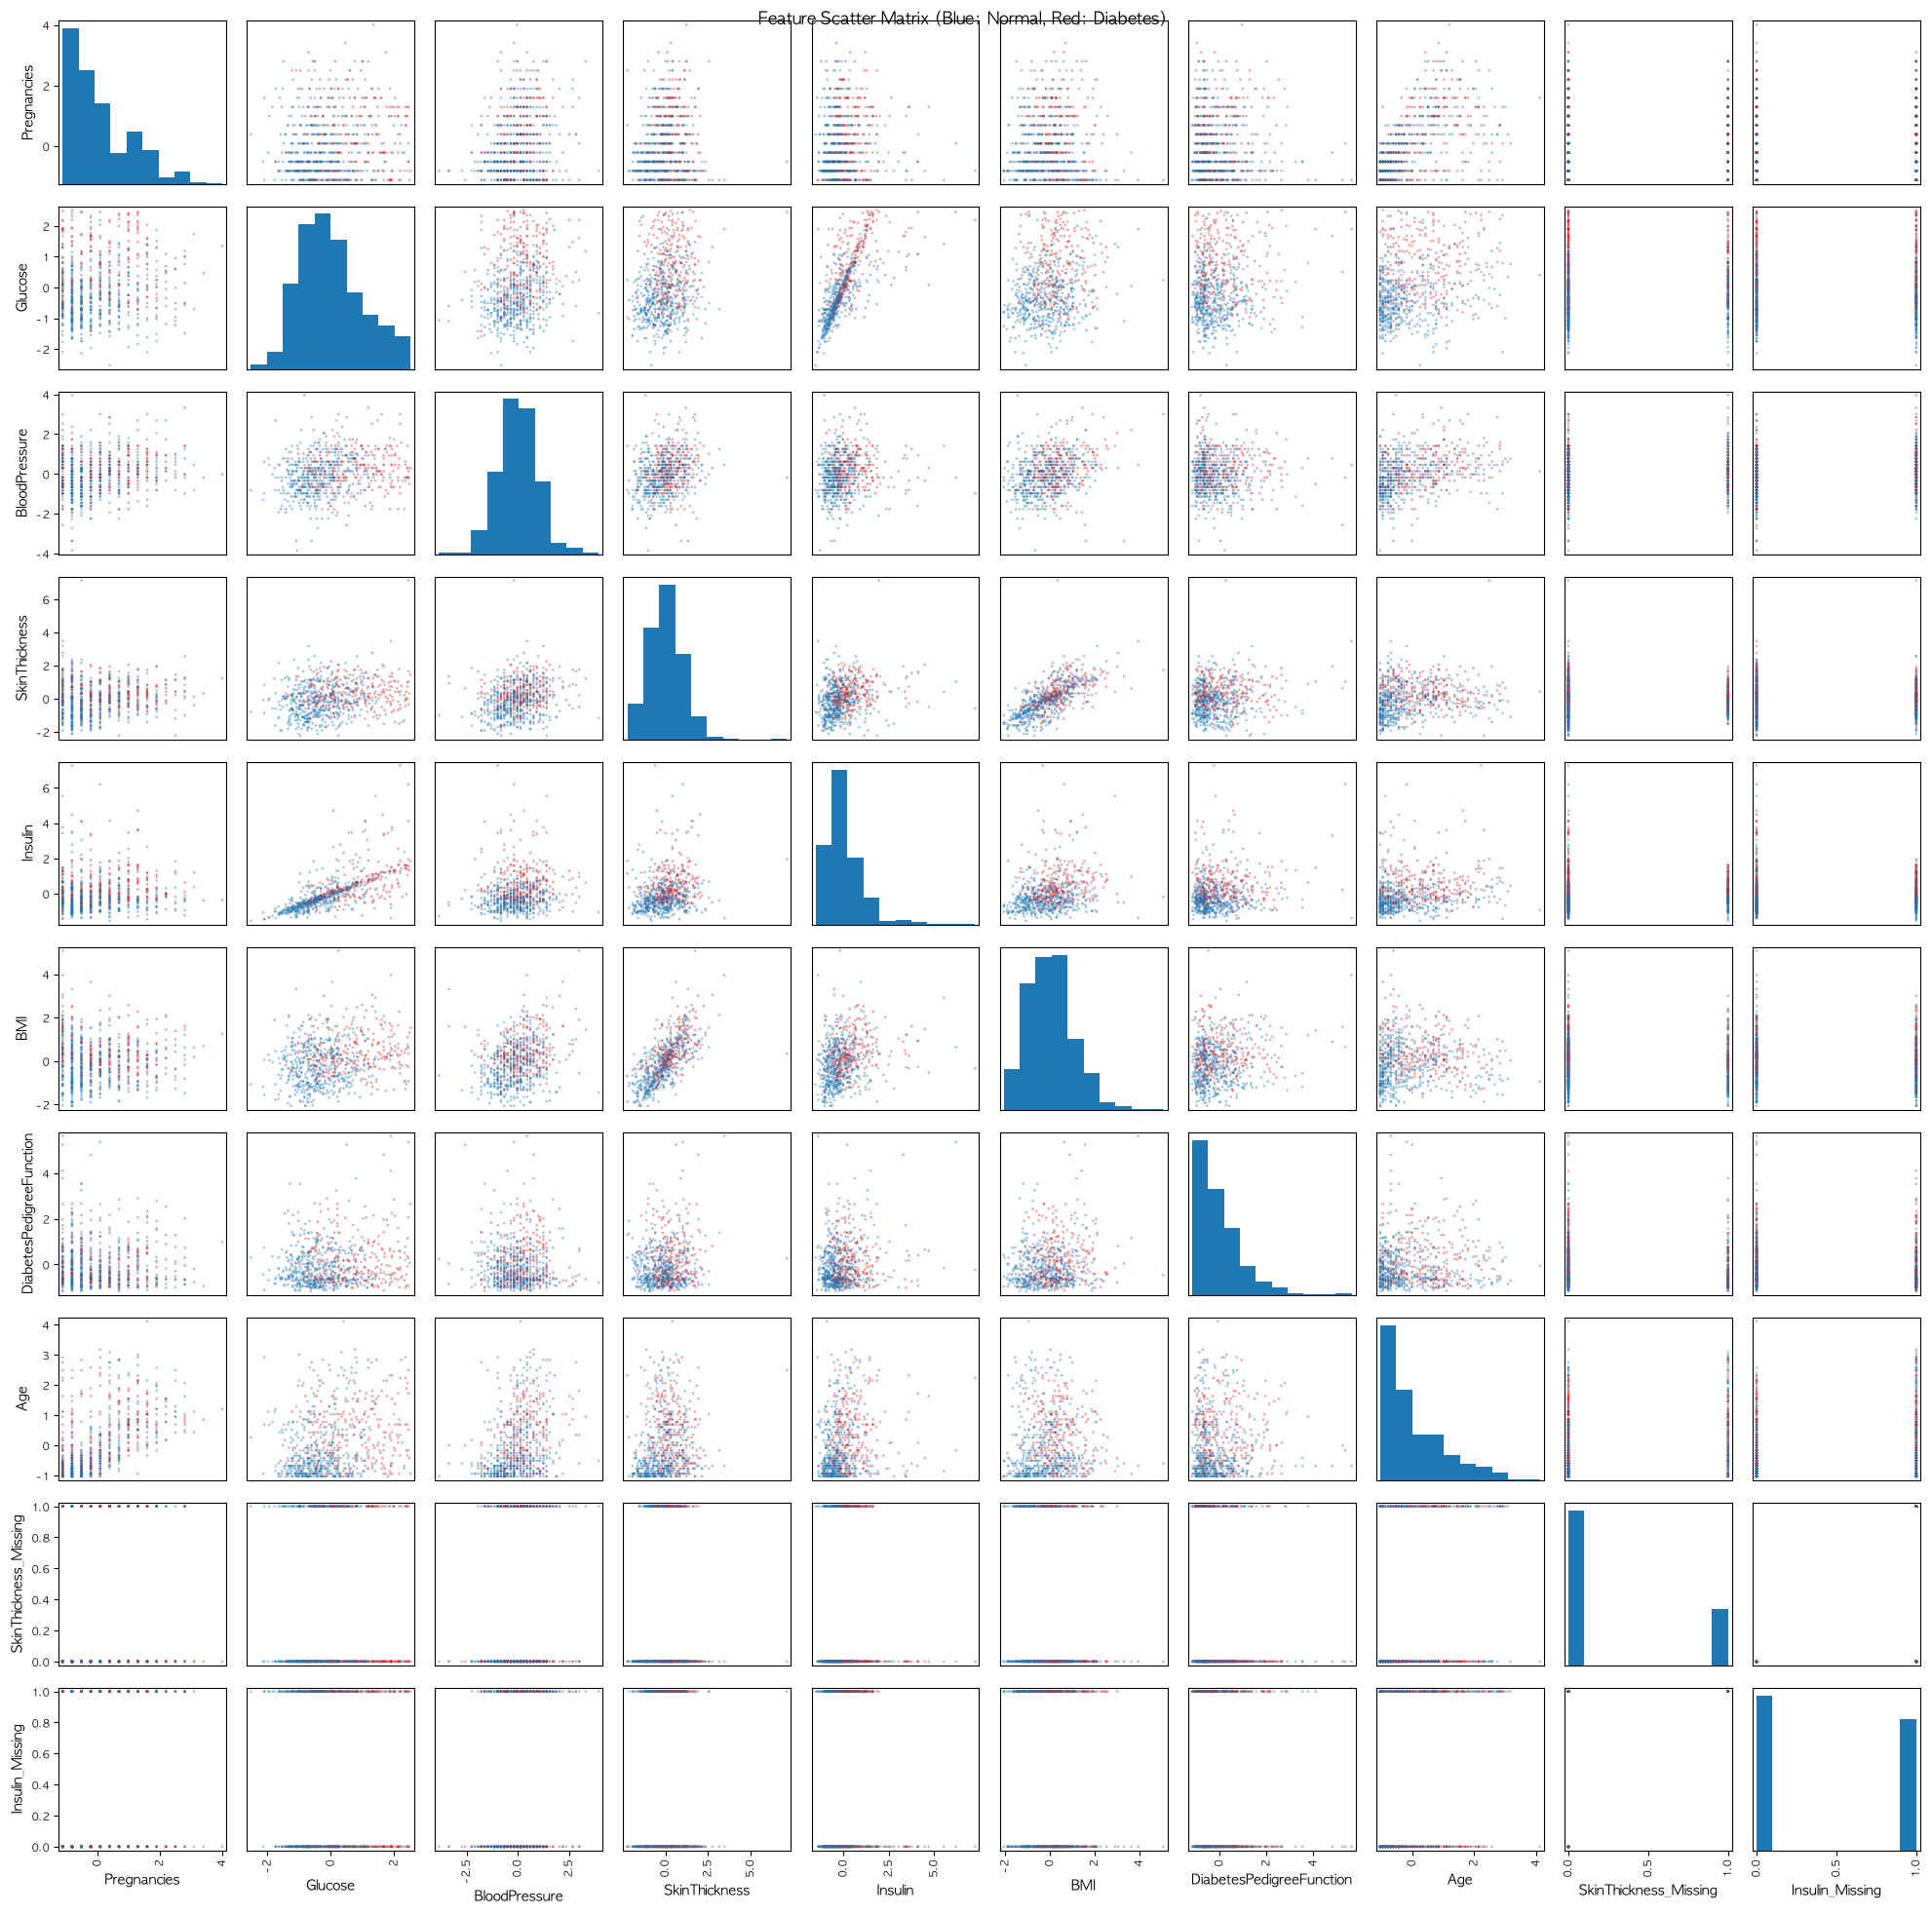

In [207]:
from pandas.plotting import scatter_matrix

# Outcome에 따라 점 색상 매핑 (0: 파랑, 1: 빨강)
colors = y.map({0: '#1f77b4', 1: '#d62728'})

axes = scatter_matrix(
    X_clean,
    c=colors, # 타겟값(당뇨여부)에 따른 컬러맵 적용
    alpha=0.4, # 컬러맵 표현을 위하여 투명값 적용
    figsize=(20, 20),
    diagonal='hist',
    s=15
)
plt.suptitle("Feature Scatter Matrix (Blue: Normal, Red: Diabetes)")
plt.tight_layout()
# 캔버스 이미지 저장 및 출력
plt.savefig("./src/img/feature_scatter_matrix_by_outcome.jpg")
plt.show()

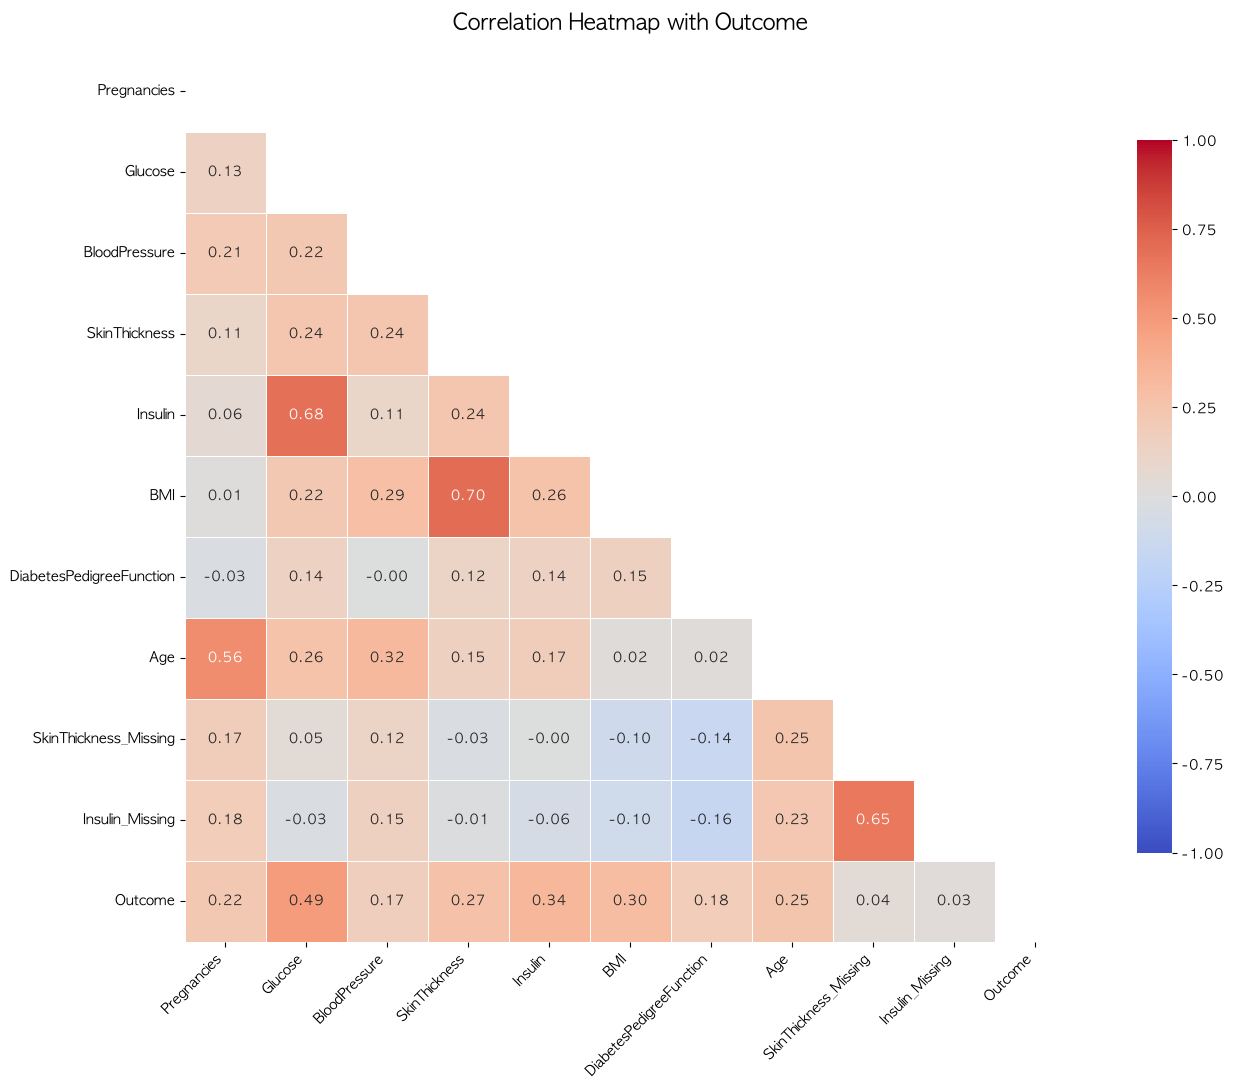

In [208]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.concat([X_clean, y], axis=1)

# 1. 상관계수 행렬 계산 (Outcome 포함)
corr = df.corr()

# 2. 대칭되는 상단 삼각형 마스크 생성 (가독성 향상)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. 히트맵 시각화
plt.figure(figsize=(14, 11))

sns.heatmap(
    corr,
    mask=mask,                  # 상단 대칭 영역 가리기
    annot=True,                 # 상관계수 숫자 표시
    fmt=".2f",                  # 소수점 둘째 자리까지
    cmap="coolwarm",            # 양/음의 상관성을 직관적으로 보여주는 컬러맵
    vmin=-1.0,
    vmax=1.0,                   # -1부터 1까지 색상 범위 고정
    linewidths=0.5,             # 셀 간격 구분선
    cbar_kws={"shrink": 0.8},   # 컬러바 크기 조절
    square=True
)

plt.title("Correlation Heatmap with Outcome", fontsize=16, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.savefig("./src/img/corr_heatmap.jpg")
plt.show()

# 2. 머신러닝 모델 학습, 과적합 점검 및 하이퍼파라미터 튜닝

**1️⃣ 구현 내용**

**[필수] 구현 내용**

| **구현 내용** | **설명** |
| --- | --- |
| **[문항 2-1] 회귀 및 분류 모델 학습과 성능 측정** | 전처리가 완료된 데이터를 사용하여 과제 목적에 맞는 회귀 모델과 분류 모델을 각각 정의하여 학습시키고, 각 모델에 부합하는 평가지표(MSE, $R^2$, Accuracy, F1-score 등)를 활용하여 모델의 성능을 측정합니다. |

**[심화] 구현 내용**

| **구현 내용** | **설명** |
| --- | --- |
| **[문항 2-2] 평가지표 선정 근거 및 예측 결과 해석** | 각 과제 유형에서 해당 평가지표를 모델 평가 기준으로 선택한 이유를 명시하고, 최종 측정된 성능 수치에 대한 분석 및 예측 오류가 발생한 원인에 대한 해석을 깊이 있게 기술합니다. |
| **[문항 2-3] 규제, 교차 검증, 하이퍼파라미터 튜닝을 통한 성능 개선** | 모델의 과적합(Overfitting)을 방지하고 성능을 고도화하기 위해 규제(Regularization), 교차 검증(Cross-Validation), 하이퍼파라미터 튜닝(GridSearchCV 등)의 3가지 요소를 모두 적용하여 모델을 개선하고, 개선 전후의 성능을 비교 분석합니다. |

**2️⃣ 결과물**

- **[문항 2-1 결과물]:** 회귀 및 분류 모델 학습 소스 코드와 선정된 평가지표의 최종 성능 수치 출력 화면
- **[문항 2-2 결과물]:** 평가지표 선택 이유, 모델 예측 성능에 대한 분석 및 오류 원인 해석 내용 (마크다운 셀)
- **[문항 2-3 결과물]:** 규제, 교차 검증, 튜닝이 반영된 모델 개선 코드 및 개선 전후의 성능 지표 비교 테이블과 기법별 효과 요약 글 (마크다운 셀)

## 기본 방향성
- 문제 : 당뇨 여부에 대한 이진 분류 예측
- 모델 : 로지스틱 회귀
  - 이유 : feature 대부분이 수치값으로 이루어져 있으며, binary feature 또한 적절하게 처리할 수 있음
- 평가지표 : Binary Cross Entropy (BCE)
  - 이유 : 이진 분류 태스크에 적합한 손실함수 (예측이 정확할수록 Loss = 0에 수렴, 예측이 틀릴수록 Loss = 무한대 증가)
- 성능개선
  - 규제 : L2(릿지) 규제
    - 이유 : Glucose-Insulin, SkinThickness-BMI 간의 강한 상관성 억제 / 극단적인 특성 배제(L1)보다는 점진적인 억제를 통해 예측력 향상 기대
  - 교차검증
    - KFold
      - 이유 : 테스트 데이터가 우연히 모델에 유리하게 구성되어 성능이 과대평가되는 오류(데이터 선택 편향) 발생 방지
  - 하이퍼파라미터 튜닝
    - GridSearchCV
      - 이유 : 상대적으로 적은 데이터샘플(~800) + 상대적으로 가벼운 ML모델(로지스틱회귀) -> 지정 범위 내의 모든 하이퍼파라미터를 로컬 머신 수준에서도 테스트 가능

### (참고/근거) 직전 데이터 시각화로부터 얻은 데이터 인사이트
* **주요 결정 인자:** `Glucose`, `Insulin`, `BMI`가 당뇨 분류(붉은색 레이블 분리)에 가장 결정적인 역할을 수행합니다.
* **다중공선성 주의 구간:** `Glucose - Insulin`($r=0.68$) 쌍과 `SkinThickness - BMI`($r=0.70$) 쌍에서 강한 공선성이 관찰됩니다.
  * 로지스틱 회귀를 적용할 때는 가중치 발산을 막기 위해 L2 규제(`C` 파라미터 조절)를 적용하거나 VIF를 점검하는 것이 필수적입니다.

In [209]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import log_loss, accuracy_score, classification_report

## 기본 Logistic Regression 학습 결과
- Test Accuracy : 0.6966
- Cross Entropy (Log Loss) : 0.5936

In [210]:
# 직전 전처리 완료 데이터셋
# X_train_final, X_test_final, y_train, y_test

lr = LogisticRegression(random_state=42) # 결과 재현을 위한 random_state
lr.fit(X_train_final, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [211]:
y_pred = lr.predict(X_test_final)
acc = accuracy_score(y_test, y_pred)
print(f"이진 분류 테스트 정확도: {acc:.4f}")

# Binary Cross-Entropy 손실 값
y_prob = lr.predict_proba(X_test_final)  # 각 target에 대한 예측 확률값
bce_loss = log_loss(y_test, y_prob)
print(f"BCE Loss : {bce_loss}")

이진 분류 테스트 정확도: 0.6966
BCE Loss : 0.5936143761207342


## 기본 Logistic Regression + KFold(k=5)
Avg. Validation Accuracy: 0.7909
- Fold별 정확도(Accuracy): [0.819  0.8448 0.7931 0.7586 0.7391]

Avg. Cross Entropy (Log Loss): 0.4521
- Fold별 Cross Entropy (Log Loss): [0.4294 0.4146 0.4487 0.4643 0.5036]

In [212]:
# KFold 설정 (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 성능 기록용 리스트
accuracies = []
log_losses = []

# 3. K-Fold 교차 검증 실행
for train_index, test_index in kf.split(X_train_final):
  # print(type(train_index), train_index)
  
  X_train_, X_test_ = X_train_final.iloc[train_index], X_train_final.iloc[test_index]
  y_train_, y_test_ = y_train.iloc[train_index], y_train.iloc[test_index]

  # 로지스틱 회귀 모델 선언 (이진분류, Binary Cross Entropy는 기본 loss_function 적용)
  model = LogisticRegression(random_state=42)

  # 모델 학습
  model.fit(X_train_, y_train_)

  # 예측 및 확률 값 계산
  y_pred = model.predict(X_test_)
  y_pred_proba = model.predict_proba(X_test_)

  # 평가 지표 계산 (정확도 및 Binary Cross Entropy / Log Loss)
  acc = accuracy_score(y_test_, y_pred)
  loss = log_loss(y_test_, y_pred_proba)

  accuracies.append(acc)
  log_losses.append(loss)

# 4. 결과 출력
print(f"Fold별 정확도(Accuracy): {np.round(accuracies, 4)}")
print(f"평균 정확도: {np.mean(accuracies):.4f}")
print(f"Fold별 Cross Entropy (Log Loss): {np.round(log_losses, 4)}")
print(f"평균 Cross Entropy (Log Loss): {np.mean(log_losses):.4f}")

Fold별 정확도(Accuracy): [0.819  0.8448 0.7931 0.7586 0.7391]
평균 정확도: 0.7909
Fold별 Cross Entropy (Log Loss): [0.4294 0.4146 0.4487 0.4643 0.5036]
평균 Cross Entropy (Log Loss): 0.4521


## Logistic Regression(L2, C=2.0) + KFold(k=5)
Avg. Validation Accuracy: 0.7927
- Fold별 정확도(Accuracy): [0.819  0.8534 0.7931 0.7586 0.7391]

Avg. Cross Entropy (Log Loss): 0.4526
- Fold별 Cross Entropy (Log Loss): [0.4297 0.4154 0.4481 0.4649 0.5051]

In [213]:
# KFold 설정 (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 성능 기록용 리스트
accuracies = []
log_losses = []

# 3. K-Fold 교차 검증 실행
for train_index, test_index in kf.split(X_train_final):
  
  X_train_, X_test_ = X_train_final.iloc[train_index], X_train_final.iloc[test_index]
  y_train_, y_test_ = y_train.iloc[train_index], y_train.iloc[test_index]

  # 로지스틱 회귀 모델 선언 (L2 규제 적용)
  model = LogisticRegression(l1_ratio=0, C=2.0, solver='lbfgs', random_state=42)

  # 모델 학습
  model.fit(X_train_, y_train_)

  # 예측 및 확률 값 계산
  y_pred = model.predict(X_test_)
  y_pred_proba = model.predict_proba(X_test_)

  # 평가 지표 계산 (정확도 및 Binary Cross Entropy / Log Loss)
  acc = accuracy_score(y_test_, y_pred)
  loss = log_loss(y_test_, y_pred_proba)

  accuracies.append(acc)
  log_losses.append(loss)

# 4. 결과 출력
print(f"Fold별 정확도(Accuracy): {np.round(accuracies, 4)}")
print(f"평균 정확도: {np.mean(accuracies):.4f}")
print(f"Fold별 Cross Entropy (Log Loss): {np.round(log_losses, 4)}")
print(f"평균 Cross Entropy (Log Loss): {np.mean(log_losses):.4f}")

Fold별 정확도(Accuracy): [0.819  0.8534 0.7931 0.7586 0.7391]
평균 정확도: 0.7927
Fold별 Cross Entropy (Log Loss): [0.4297 0.4154 0.4481 0.4649 0.5051]
평균 Cross Entropy (Log Loss): 0.4526


In [214]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 탐색할 하이퍼파라미터 그리드 설정
# - C: 규제 강도의 역수 (작을수록 강한 규제)
# - l1_ratio : 규제 종류, l1_ratio=0 for L2, l1_ratio=1 for L1
# - solver: 최적화에 사용할 알고리즘
param_grid = [{
    'C': np.logspace(-2, 2, 19),
    'l1_ratio': [1, 0], # l1_ratio=0 for L2, l1_ratio=1 for L1
    'solver': ['liblinear'],
    'max_iter' : [50, 100, 1000, 5000]
},
{
    'C': np.logspace(-2, 2, 19),
    'l1_ratio': [0], # l1_ratio=0 for L2, l1_ratio=1 for L1
    'solver': ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag'],
    'max_iter' : [50, 100, 1000, 5000]
}             
]


# 5. 로지스틱 회귀 모델 초기화
# Increased max_iter helps solvers converge
lr_model = LogisticRegression(random_state=42)

# 6. GridSearchCV 객체 생성
# - cv=5: 5-Fold 교차 검증 사용
# - scoring='neg_log_loss': 이진 분류 평가지표로 Binary Cross Entropy 사용
grid_search = GridSearchCV(estimator=lr_model, param_grid=param_grid, cv=kf, scoring='neg_log_loss', n_jobs=-1)

# 7. 그리드 서치 수행 (학습)
grid_search.fit(X_train_final, y_train)

# 8. 최적의 파라미터 및 최고 점수 출력
print(f"최적의 하이퍼파라미터: {grid_search.best_params_}")
print(f"교차 검증 최저 손실값: {-1 * grid_search.best_score_:.4f}")

# 9. 베스트 모델 최종 test accuracy 출력
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_final)
acc = accuracy_score(y_test, y_pred)

print(f"GridSearch 베스트 모델 - 이진 분류 테스트 정확도: {acc:.4f}")

최적의 하이퍼파라미터: {'C': np.float64(0.3593813663804626), 'l1_ratio': 1, 'max_iter': 50, 'solver': 'liblinear'}
교차 검증 최저 손실값: 0.4485
GridSearch 베스트 모델 - 이진 분류 테스트 정확도: 0.7034


# 3. Hugging Face 사전 학습된 모델을 활용한 뉴스 기사 분류 및 추론

**1️⃣ 구현 내용**

**[필수] 구현 내용**

| **구현 내용** | **설명** |
| --- | --- |
| **[문항 3-1] 사전 학습된 모델 및 토크나이저 로드** | Hugging Face 라이브러리를 활용하여 사전 학습된(Pre-trained) Gemma 모델과 토크나이저를 독립된 개발 환경 내에 그대로 로드하는 코드를 구현합니다. |
| **[문항 3-2] 문맥 내 학습(In-context Learning) 기반 뉴스 기사 분류 추론** | 뉴스 기사 텍스트를 분류하기 위해, 프롬프트 내에 정답 카테고리 예시들을 제공하는 Few-shot 프롬프트 구조(문맥 내 학습)를 설계합니다. 별도의 가중치 파인튜닝 없이 사전 학습된 가중치 그대로 뉴스 기사 텍스트를 입력하여 카테고리 추론(Inference) 결과를 도출합니다. |

**[심화] 구현 내용**

| **구현 내용** | **설명** |
| --- | --- |
| **[문항 3-3] Generation 하이퍼파라미터 변경 실험 및 성능 비교 해석** |   • 텍스트 생성 결과의 다양성과 무작위성을 제어하는 **Generation 하이퍼파라미터(temperature, top_p , top_k 등) 설정을 변경**하거나 프롬프트 내 Few-shot 예시의 개수를 바꾸어 추가 추론 실험을 수행합니다.
  • 하이퍼파라미터 조건 변경에 따라 모델이 출력한 분류 결과의 정확도와 답변의 일관성이 어떻게 변화하는지 비교 분석하고 해석하는 내용을 마크다운 셀에 기술합니다. |

**2️⃣ 결과물**

- **[문항 3-1 결과물]:** Hugging Face 기반 사전학습 Gemma 모델 및 토크나이저 로드 소스 코드와 출력 화면
- **[문항 3-2 결과물]:** 문맥 내 학습(Few-shot)을 위한 프롬프트 구성 및 추론 프로세스 구현 코드와 카테고리 분류 출력 화면
- **[문항 3-3 결과물]:** 생성 하이퍼파라미터 설정별 변경 실험 조건 표 및 결과에 따른 출력 성능 비교 분석 내용 (마크다운 셀)

교안
* https://teamsparta.notion.site/3ae2dc3ef51480488366d3386c5c5cc1

과제제출가이드
* https://teamsparta.notion.site/AX_1-Ch-1-3c72dc3ef51480b7abbaedb953ca28dd
* https://app.notion.com/p/teamsparta/KANT-3d02dc3ef51480c599c2c80fb53be7aa
